# `stata-mpl` — a complete tutorial

`stata-mpl` makes **matplotlib** and **seaborn** charts look like **Stata 19**
(the `stcolor` colorblind-friendly scheme), calibrated against Stata's official
SVG exports.

This notebook is a hands-on tutorial that covers **every chart type**. The
recommended entry point is the context manager **`stata_mpl.theme()`**, which:

1. applies the Stata style (palette, grid, fonts, balanced margins);
2. sets the stcolor palette for seaborn (no `palette=` needed for `hue`);
3. puts **every** legend outside, to the right of the frame — like Stata;
4. gives `axvline` / `axhline` the Stata reference-line look (grid dashes, black).

> **Install:** `pip install -e ".[seaborn]"` from the repo. The next cell makes
> the package importable directly from the source tree.

In [1]:
# Make stata_mpl importable even without 'pip install'.
try:
    import stata_mpl
except ImportError:
    import sys, pathlib
    here = pathlib.Path.cwd()
    for cand in (here, here.parent, here.parent.parent):
        if (cand / 'stata_mpl' / '__init__.py').exists():
            sys.path.insert(0, str(cand)); break
    import stata_mpl

%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

rng = np.random.default_rng(7)
penguins = sns.load_dataset('penguins').dropna()
flights = sns.load_dataset('flights')
tips = sns.load_dataset('tips')
NUM = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']
print('stata_mpl', stata_mpl.__version__)

stata_mpl 0.3.0


## 1 — Palette and colormaps

The stcolor categorical palette and the registered colormaps. Diverging maps are
great for correlations; `stata-heat` is Stata's native multicolor heatmap map.

PALETTE: ['#1A85FF', '#D41159', '#00BF7F', '#FFD400', '#4F2C99'] ...
lighten #1A85FF -> (0.5509803921568628, 0.7607843137254902, 1.0)


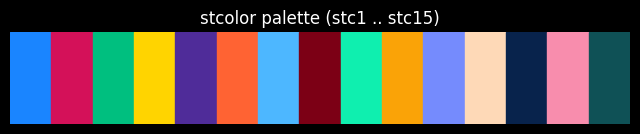

In [2]:
print('PALETTE:', stata_mpl.palette(5), '...')
print('lighten #1A85FF ->', stata_mpl.lighten('#1A85FF'))   # Stata box fill #8DC2FF

# categorical swatches
fig, ax = plt.subplots(figsize=(8, 1.2))
for i, c in enumerate(stata_mpl.PALETTE):
    ax.add_patch(plt.Rectangle((i, 0), 1, 1, color=c))
ax.set(xlim=(0, len(stata_mpl.PALETTE)), ylim=(0, 1)); ax.set_axis_off()
ax.set_title('stcolor palette (stc1 .. stc15)')
plt.show()

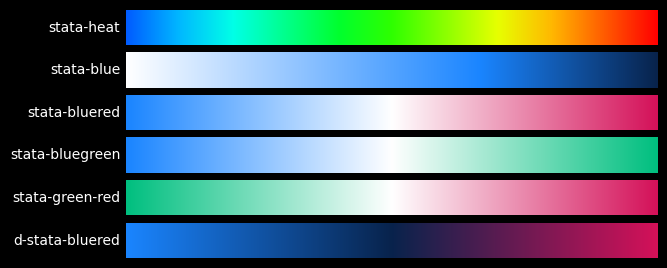

In [3]:
# colormaps
names = ['stata-heat', 'stata-blue', 'stata-bluered', 'stata-bluegreen',
         'stata-green-red', 'd-stata-bluered']
grad = np.linspace(0, 1, 256).reshape(1, -1)
fig, axs = plt.subplots(len(names), 1, figsize=(7, 0.45 * len(names)))
for ax, n in zip(axs, names):
    ax.imshow(grad, aspect='auto', cmap=n); ax.set_axis_off()
    ax.text(-0.01, 0.5, n, ha='right', va='center', transform=ax.transAxes)
fig.subplots_adjust(left=0.22, right=0.98, top=0.96, bottom=0.04)
plt.show()

## 2 — matplotlib charts

Use `stata_mpl.theme(overlay)` and draw as usual. `stata_mpl.legend(ax)` draws
the borderless legend outside the frame.

### 2.1 Line plot + reference lines

`axvline`/`axhline` automatically take the grid look in black inside `theme()`.

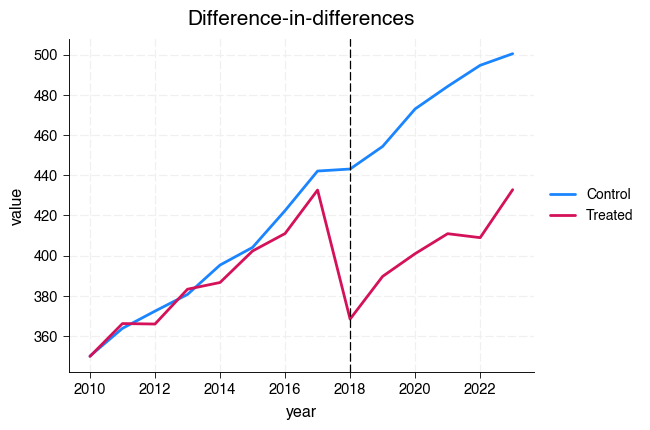

In [4]:
years = np.arange(2010, 2024)
trend = 350 + 12 * (years - 2010)
control = trend + rng.normal(0, 6, years.size)
treated = trend + rng.normal(0, 6, years.size); treated[years >= 2018] -= 70

with stata_mpl.theme('line'):
    fig, ax = plt.subplots()
    ax.plot(years, control, label='Control')
    ax.plot(years, treated, label='Treated')
    ax.axvline(2018)                       # reference line, grid-black
    ax.set(title='Difference-in-differences', xlabel='year', ylabel='value')
    stata_mpl.legend(ax)
    plt.show()

### 2.2 Scatter

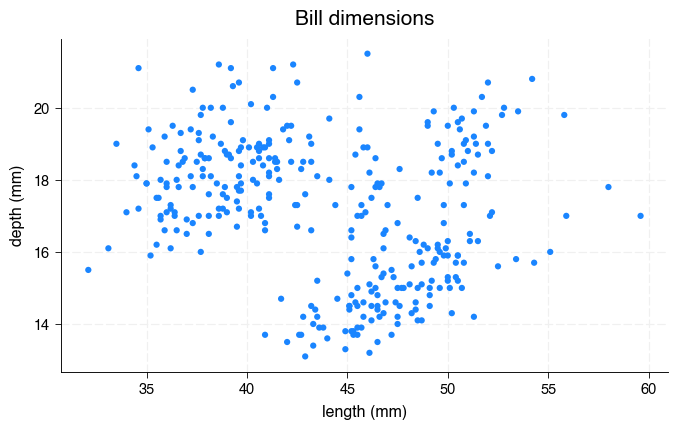

In [5]:
with stata_mpl.theme('scatter'):
    fig, ax = plt.subplots()
    ax.scatter(penguins.bill_length_mm, penguins.bill_depth_mm)
    ax.set(title='Bill dimensions', xlabel='length (mm)', ylabel='depth (mm)')
    plt.show()

### 2.3 Bar and horizontal bar

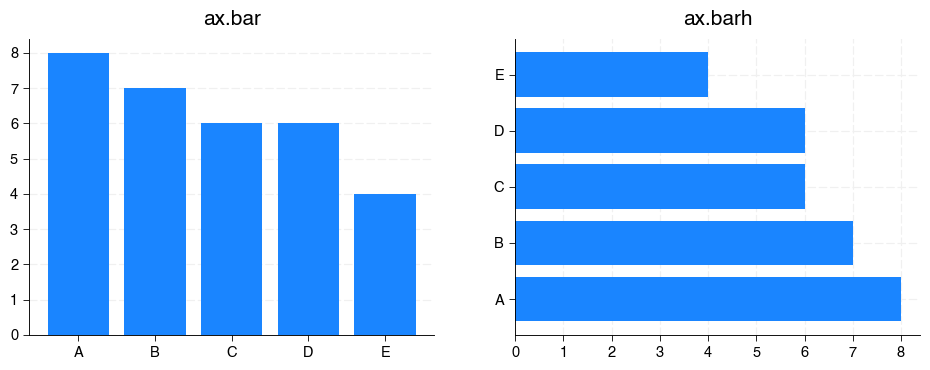

In [6]:
with stata_mpl.theme('bar'):
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))
    cats = list('ABCDE'); vals = rng.integers(3, 10, 5)
    axs[0].bar(cats, vals); axs[0].set_title('ax.bar')
    axs[1].barh(cats, vals); axs[1].grid(axis='x'); axs[1].set_title('ax.barh')
    plt.show()

### 2.4 Histogram

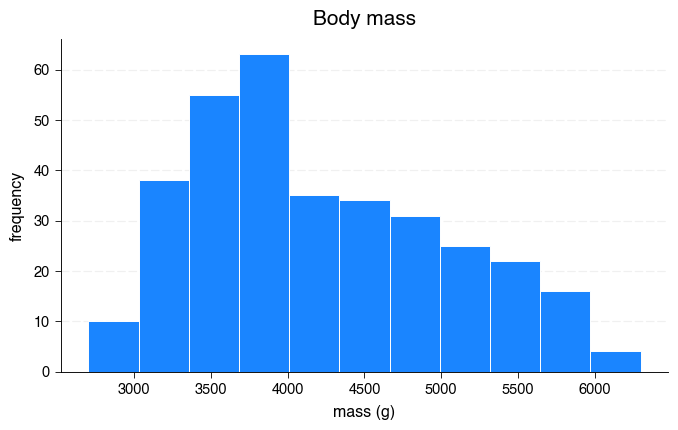

In [7]:
with stata_mpl.theme('histogram'):
    fig, ax = plt.subplots()
    ax.hist(penguins.body_mass_g, bins='auto')
    ax.set(title='Body mass', xlabel='mass (g)', ylabel='frequency')
    plt.show()

### 2.5 Stacked area

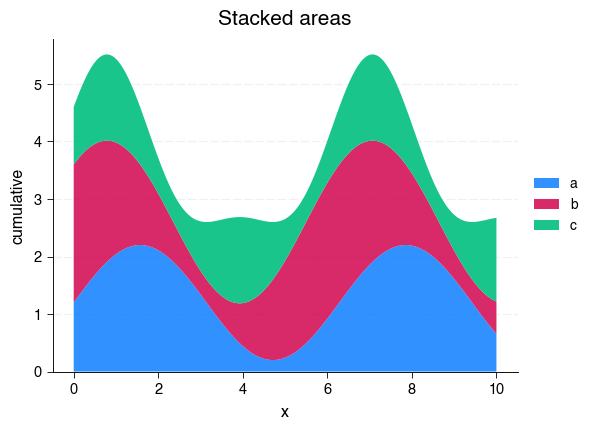

In [8]:
x = np.linspace(0, 10, 200)
ys = np.abs([np.sin(x) + 1.2, np.cos(x) + 1.4, 0.5 * np.sin(2 * x) + 1.0])
with stata_mpl.theme('area'):
    fig, ax = plt.subplots()
    ax.stackplot(x, ys, labels=['a', 'b', 'c'], alpha=0.9)
    ax.set(title='Stacked areas', xlabel='x', ylabel='cumulative')
    stata_mpl.legend(ax)
    plt.show()

### 2.6 Pie

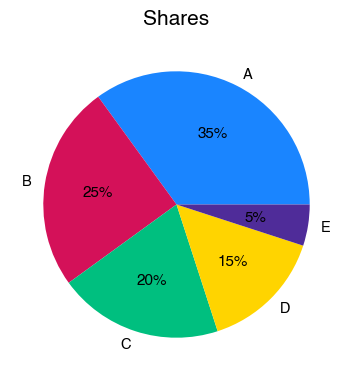

In [9]:
with stata_mpl.theme('pie'):
    fig, ax = plt.subplots()
    ax.pie([35, 25, 20, 15, 5], labels=list('ABCDE'), autopct='%1.0f%%')
    ax.set_title('Shares')
    plt.show()

### 2.7 Error bars

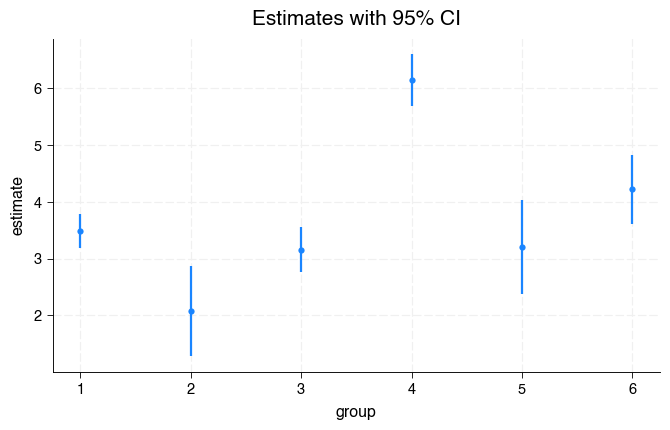

In [10]:
with stata_mpl.theme('errorbar'):
    fig, ax = plt.subplots()
    xs = np.arange(1, 7); ys = rng.uniform(2, 8, 6)
    ax.errorbar(xs, ys, yerr=rng.uniform(0.3, 0.9, 6), fmt='o')
    ax.set(title='Estimates with 95% CI', xlabel='group', ylabel='estimate')
    plt.show()

### 2.8 Step and stem

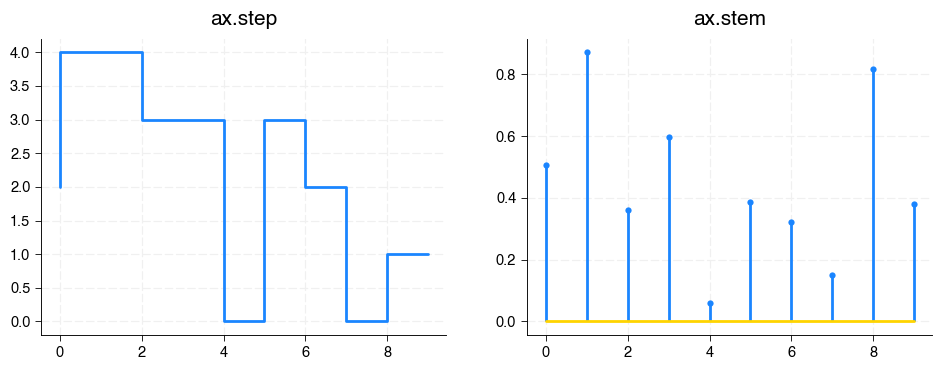

In [11]:
with stata_mpl.theme('line'):
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))
    axs[0].step(np.arange(10), rng.integers(0, 5, 10)); axs[0].set_title('ax.step')
    axs[1].stem(np.arange(10), rng.random(10)); axs[1].set_title('ax.stem')
    plt.show()

## 3 — Stata-look seaborn wrappers

Seaborn draws box/violin/heatmap with its own artists, so a style sheet can't
fully reach them. The wrappers below reproduce Stata's per-group look (light
fill + colored outline) and place the legend outside. They take the same
arguments as their `sns.*` counterparts.

### 3.1 Box plot — per-group colors, even with unbalanced groups

Each box keeps the color seaborn assigned to its group, so the mapping stays correct even when some combinations are missing (here Gentoo lives only on Biscoe and Chinstrap only on Dream).

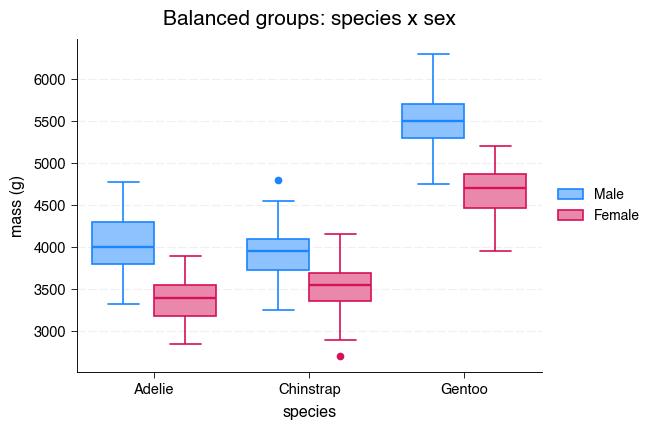

In [12]:
with stata_mpl.theme():
    fig, ax = plt.subplots()
    stata_mpl.boxplot(penguins, x='species', y='body_mass_g', hue='sex', ax=ax)
    ax.set(title='Balanced groups: species x sex', xlabel='species', ylabel='mass (g)')
    plt.show()

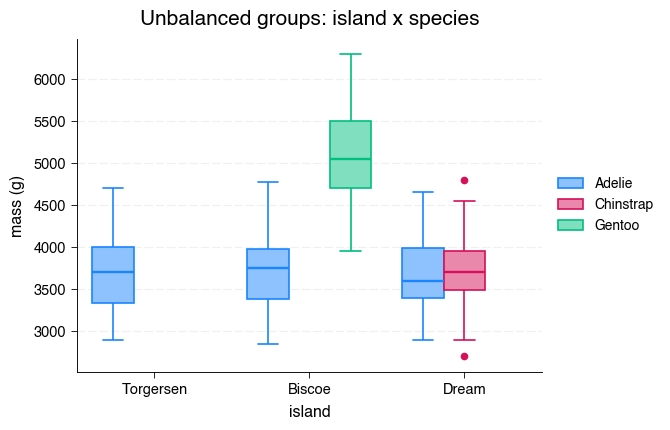

In [13]:
with stata_mpl.theme():
    fig, ax = plt.subplots()
    # island x species is UNBALANCED (Gentoo only on Biscoe, Chinstrap only on Dream)
    stata_mpl.boxplot(penguins, x='island', y='body_mass_g', hue='species', ax=ax)
    ax.set(title='Unbalanced groups: island x species', xlabel='island', ylabel='mass (g)')
    plt.show()

### 3.2 Violin plot

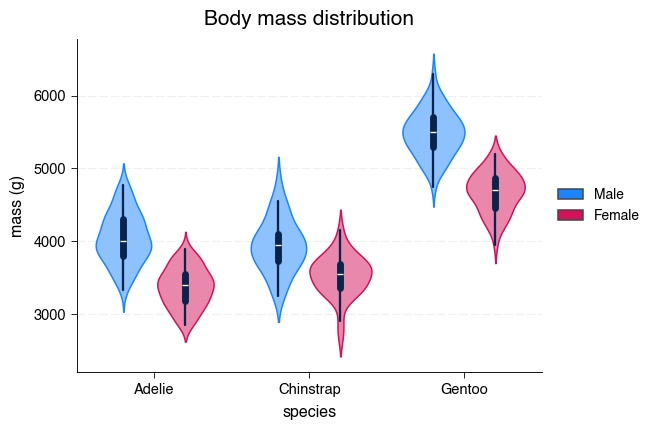

In [14]:
with stata_mpl.theme():
    fig, ax = plt.subplots()
    stata_mpl.violinplot(penguins, x='species', y='body_mass_g', hue='sex', ax=ax)
    ax.set(title='Body mass distribution', xlabel='species', ylabel='mass (g)')
    plt.show()

### 3.3 Heatmap — Stata's native multicolor map

`stata_mpl.heatmap` uses `stata-heat` by default and leaves the Stata gap between the cells and the frame.

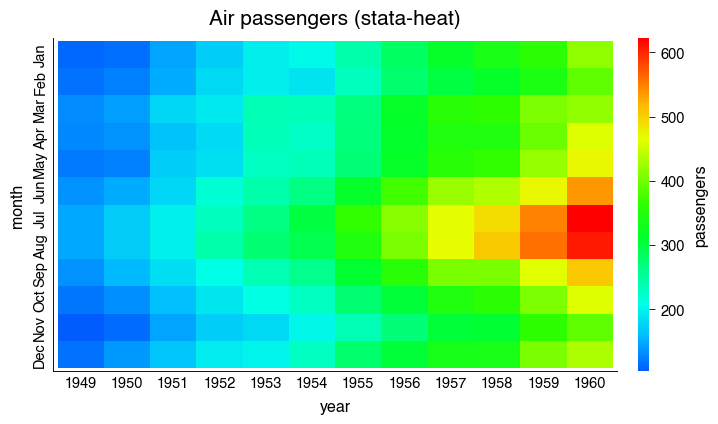

In [15]:
pivot = flights.pivot(index='month', columns='year', values='passengers')
with stata_mpl.theme():
    fig, ax = plt.subplots(figsize=(8.5, 4.5))
    stata_mpl.heatmap(pivot, ax=ax, cbar_kws={'label': 'passengers'})
    ax.set(title='Air passengers (stata-heat)', xlabel='year', ylabel='month')
    plt.show()

### 3.4 Correlation heatmap — diverging map

For correlations, pass a diverging colormap such as `stata-bluered`.

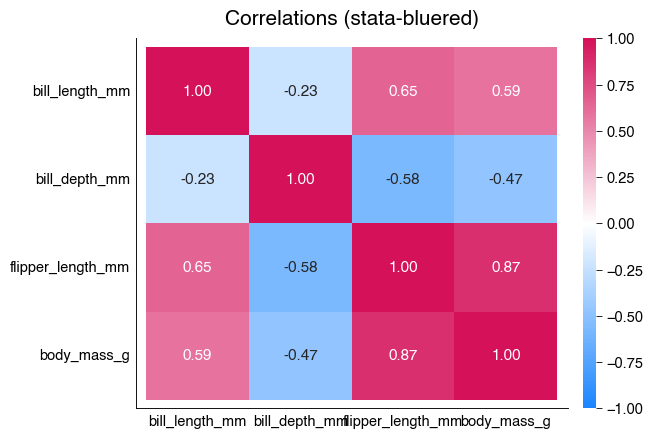

In [16]:
with stata_mpl.theme():
    fig, ax = plt.subplots(figsize=(6.5, 5))
    stata_mpl.heatmap(penguins[NUM].corr(), cmap='stata-bluered', vmin=-1, vmax=1,
                      annot=True, fmt='.2f', ax=ax)
    ax.set_title('Correlations (stata-bluered)')
    plt.show()

### 3.5 Jointplot — less zoom, legend outside

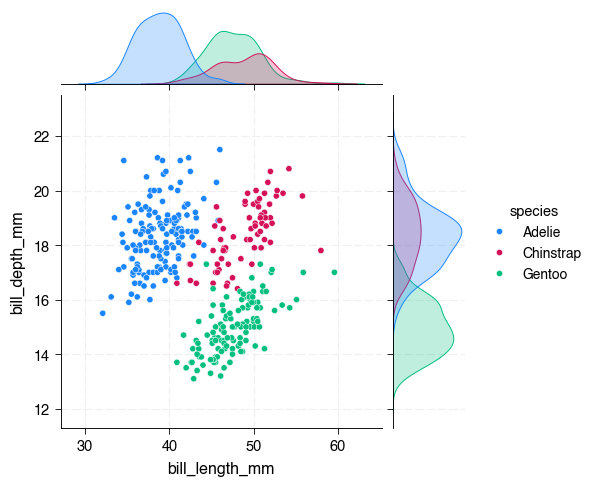

In [17]:
with stata_mpl.theme():
    g = stata_mpl.jointplot(penguins, x='bill_length_mm', y='bill_depth_mm',
                            hue='species')
    plt.show()

### 3.6 Bubble plot — open circles sized by a third variable

Like Stata's weighted scatter, markers are hollow rings sized by `size`.

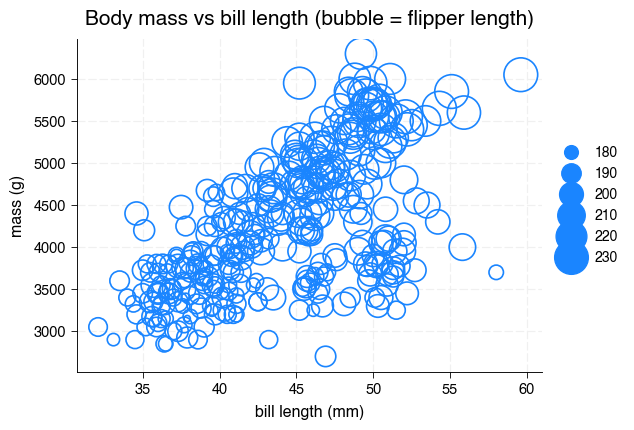

In [18]:
with stata_mpl.theme('scatter'):
    fig, ax = plt.subplots()
    stata_mpl.bubbleplot(penguins, x='bill_length_mm', y='body_mass_g',
                         size='flipper_length_mm', ax=ax)
    ax.set(title='Body mass vs bill length (bubble = flipper length)',
           xlabel='bill length (mm)', ylabel='mass (g)')
    plt.show()

### 3.7 Marker labels — Stata-style annotations

`stata_mpl.label_points` writes the labels in the marker's color, and continuous-continuous scatters show **both** grids.

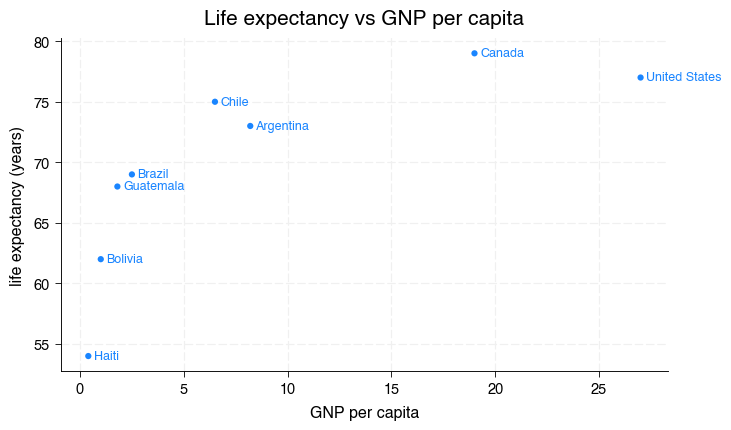

In [19]:
gnp = pd.DataFrame({
    'gnp':  [1.0, 2.5, 8.2, 19, 27, 0.4, 1.8, 6.5],
    'life': [62,  69,  73,  79, 77, 54,  68,  75],
    'country': ['Bolivia', 'Brazil', 'Argentina', 'Canada', 'United States',
                'Haiti', 'Guatemala', 'Chile']})
with stata_mpl.theme('scatter'):
    fig, ax = plt.subplots()
    ax.scatter(gnp.gnp, gnp.life)
    stata_mpl.label_points(ax, gnp.gnp, gnp.life, gnp.country)
    ax.set(title='Life expectancy vs GNP per capita',
           xlabel='GNP per capita', ylabel='life expectancy (years)')
    plt.show()

## 4 — seaborn axes-level plots

Call seaborn as usual inside `theme()`: the stcolor palette is applied and the
legend goes outside automatically — no `palette=` argument needed.

### 4.1 Scatter and line

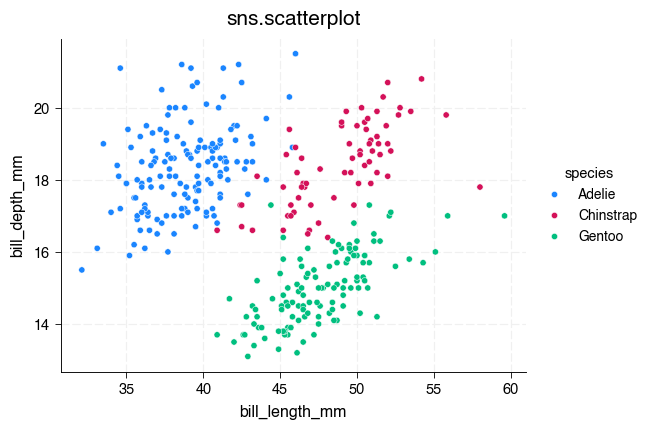

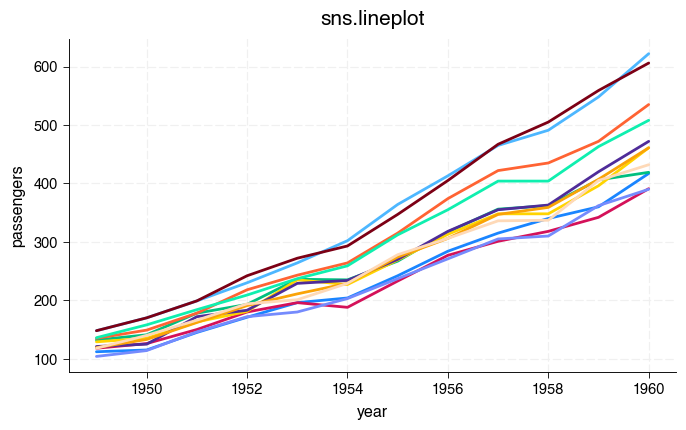

In [20]:
with stata_mpl.theme('scatter'):
    fig, ax = plt.subplots()
    sns.scatterplot(penguins, x='bill_length_mm', y='bill_depth_mm', hue='species', ax=ax)
    ax.set_title('sns.scatterplot'); plt.show()

with stata_mpl.theme('line'):
    fig, ax = plt.subplots()
    sns.lineplot(flights, x='year', y='passengers', hue='month', ax=ax, legend=False)
    ax.set_title('sns.lineplot'); plt.show()

### 4.2 Histogram and KDE

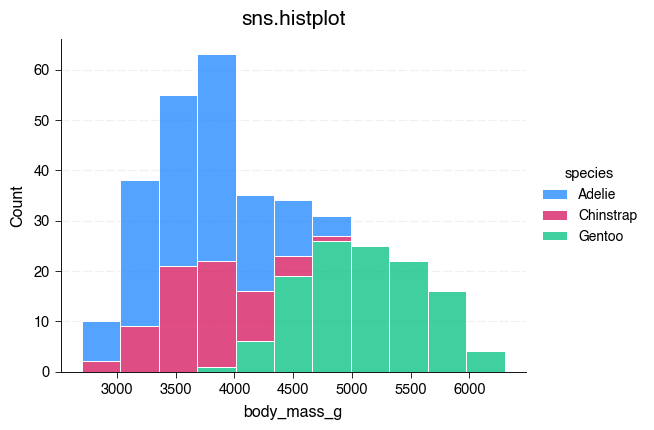

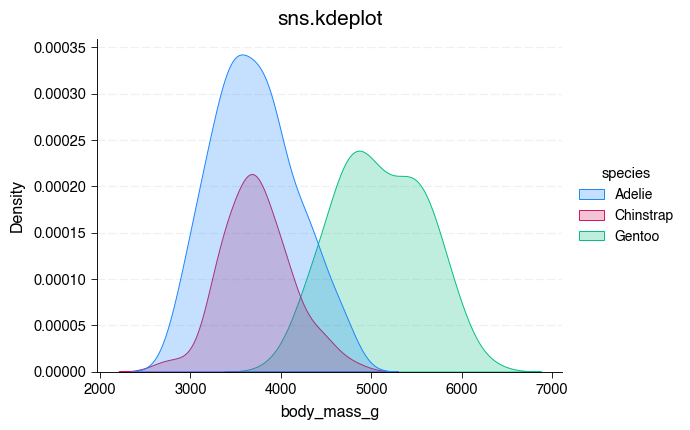

In [21]:
with stata_mpl.theme('histogram'):
    fig, ax = plt.subplots()
    sns.histplot(penguins, x='body_mass_g', hue='species', multiple='stack', ax=ax)
    ax.set_title('sns.histplot'); plt.show()

with stata_mpl.theme():
    fig, ax = plt.subplots()
    sns.kdeplot(penguins, x='body_mass_g', hue='species', fill=True, ax=ax)
    ax.set_title('sns.kdeplot'); plt.show()

### 4.3 Bar and point

`stata_mpl.pointplot` shows point estimates with capped CIs (no connecting line), like a Stata point/range plot.

/var/folders/_k/stmct6ys4r79zdcl4lnxhjp40000gn/T/ipykernel_32788/266827741.py:3: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(penguins, x='species', y='body_mass_g', hue='sex', ax=ax, ci=None)


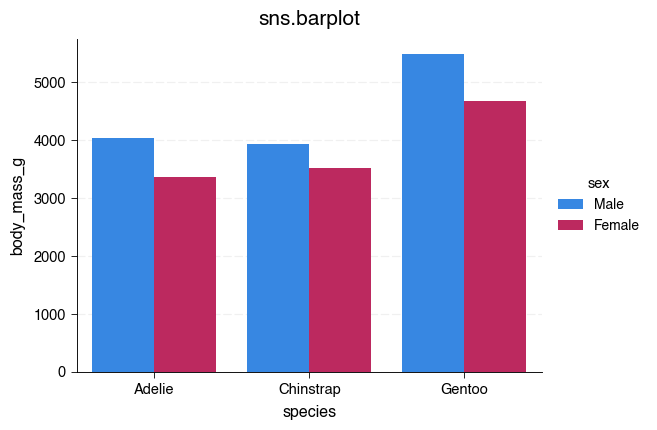

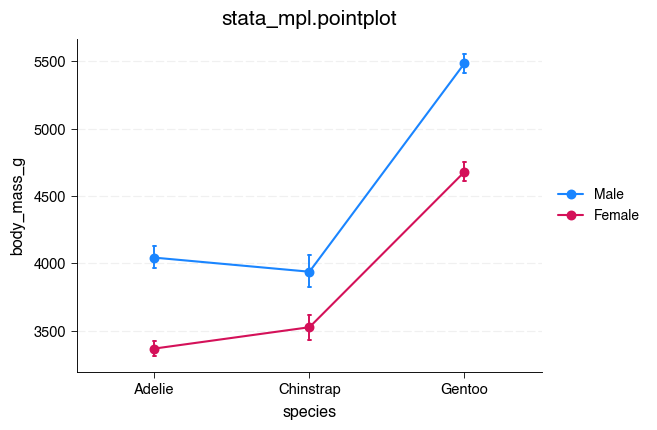

In [42]:
with stata_mpl.theme('bar'):
    fig, ax = plt.subplots()
    sns.barplot(penguins, x='species', y='body_mass_g', hue='sex', ax=ax, ci=None)
    ax.set_title('sns.barplot'); plt.show()

with stata_mpl.theme():
    fig, ax = plt.subplots()
    stata_mpl.pointplot(penguins, x='species', y='body_mass_g', ax=ax, hue='sex')
    ax.set_title('stata_mpl.pointplot'); plt.show()

### 4.4 Strip and swarm

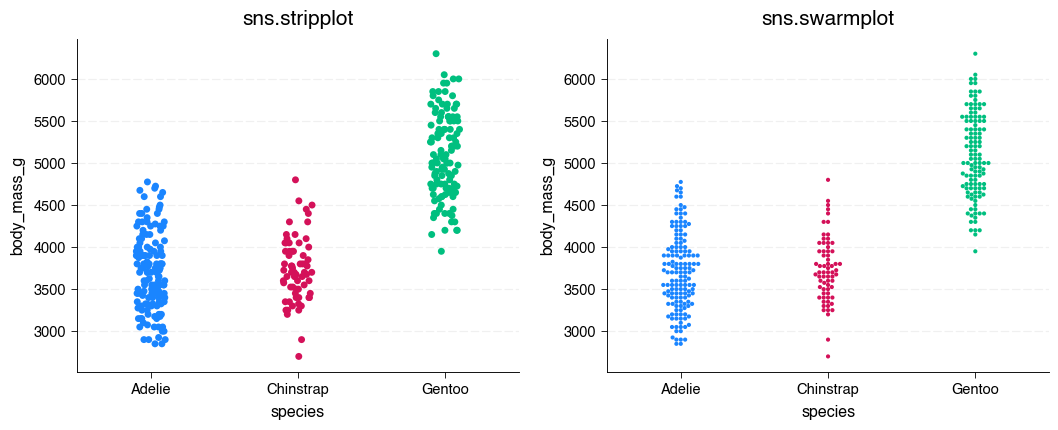

In [23]:
with stata_mpl.theme():
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.stripplot(penguins, x='species', y='body_mass_g', hue='species',
                  legend=False, ax=axs[0]); axs[0].set_title('sns.stripplot')
    sns.swarmplot(penguins, x='species', y='body_mass_g', hue='species',
                  legend=False, size=3, ax=axs[1]); axs[1].set_title('sns.swarmplot')
    plt.show()

### 4.5 Regression and residuals

`stata_mpl.residplot` draws the y=0 baseline as a Stata reference line (grid dashes, black).

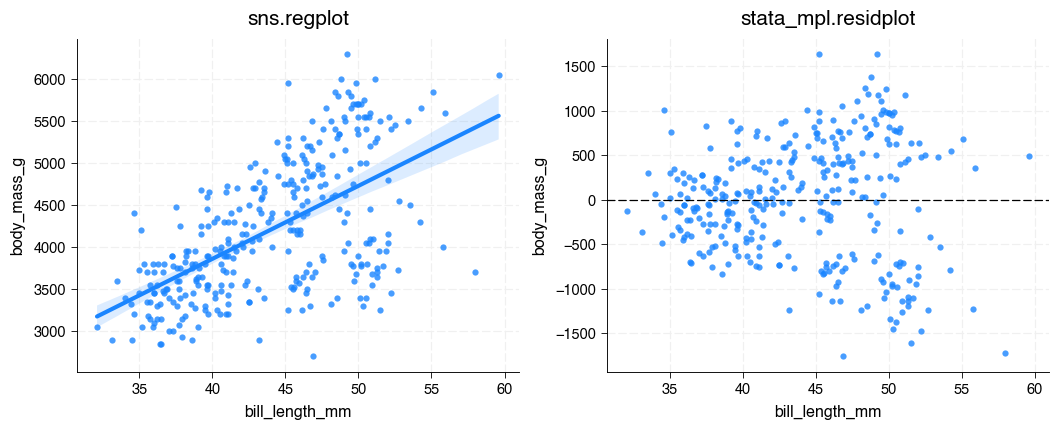

In [24]:
with stata_mpl.theme(['line']):
    fig, axs = plt.subplots(1, 2, figsize=(12, 4.5))
    sns.regplot(penguins, x='bill_length_mm', y='body_mass_g', ax=axs[0])
    axs[0].set_title('sns.regplot')
    stata_mpl.residplot(penguins, x='bill_length_mm', y='body_mass_g', ax=axs[1])
    axs[1].set_title('stata_mpl.residplot')
    plt.show()

## 5 — seaborn figure-level plots

Figure-level functions (`pairplot`, `lmplot`, `catplot`, `displot`, `relplot`)
build their own figure; they still pick up the Stata style inside `theme()`.

### 5.1 Pairplot

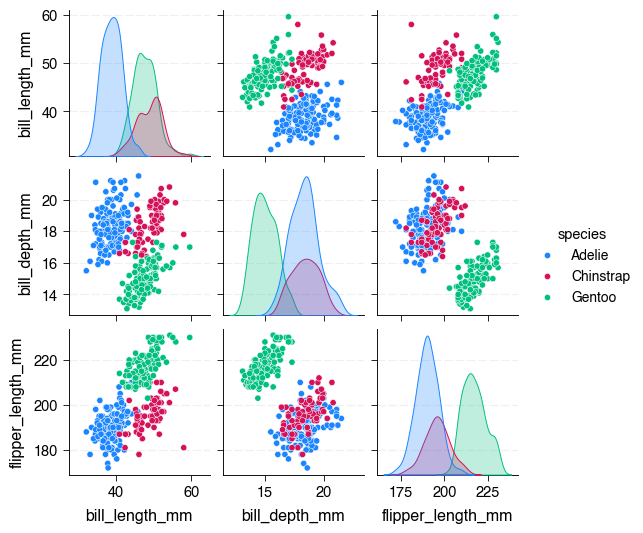

In [25]:
with stata_mpl.theme():
    g = sns.pairplot(penguins, vars=NUM[:3], hue='species', height=1.8)
    plt.show()

### 5.2 lmplot and catplot

`stata_mpl.catplot` applies the Stata box/violin look to every facet (plain `sns.catplot` leaves seaborn's default colors).

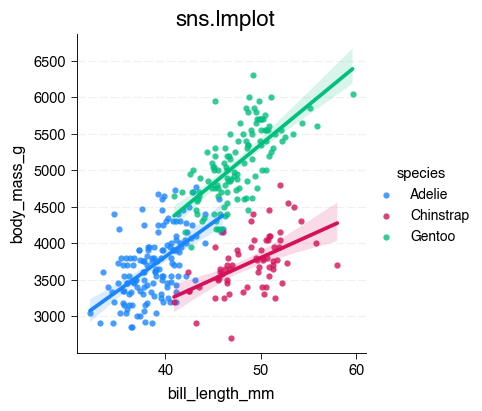

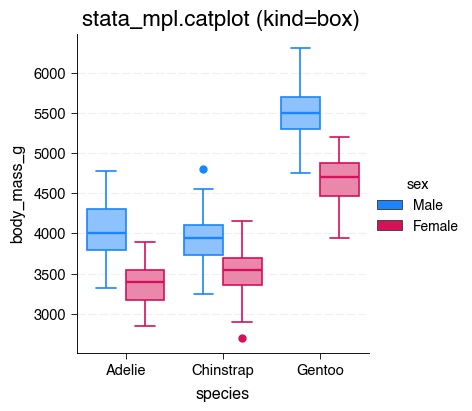

In [26]:
with stata_mpl.theme():
    g = sns.lmplot(penguins, x='bill_length_mm', y='body_mass_g', hue='species', height=4)
    g.figure.suptitle('sns.lmplot', y=1.02); plt.show()

with stata_mpl.theme():
    g = stata_mpl.catplot(penguins, x='species', y='body_mass_g', hue='sex',
                          kind='box', height=4)
    g.figure.suptitle('stata_mpl.catplot (kind=box)', y=1.02); plt.show()

### 5.3 displot and relplot

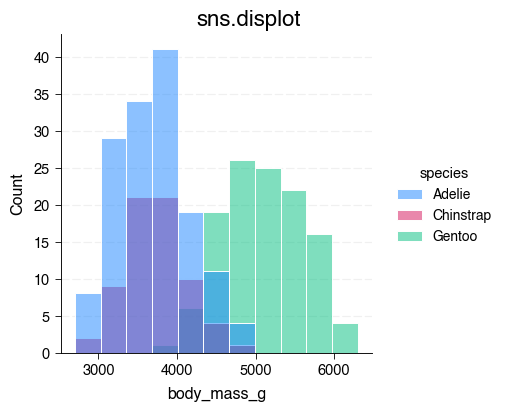

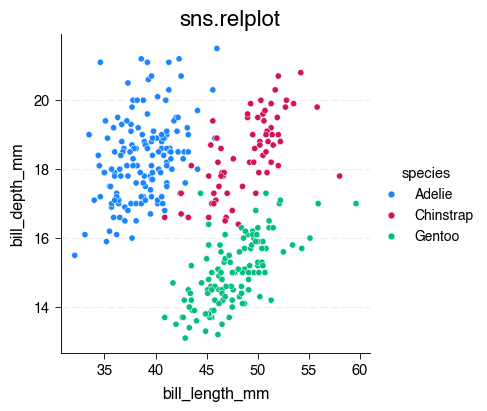

In [27]:
with stata_mpl.theme():
    g = sns.displot(penguins, x='body_mass_g', hue='species', kind='hist', height=4)
    g.figure.suptitle('sns.displot', y=1.02); plt.show()

with stata_mpl.theme():
    g = sns.relplot(penguins, x='bill_length_mm', y='bill_depth_mm', hue='species', height=4)
    g.figure.suptitle('sns.relplot', y=1.02); plt.show()

## 6 — Image and contour plots

With the `heatmap` overlay, `imshow` / `contourf` / `pcolormesh` use the native
`stata-heat` colormap.

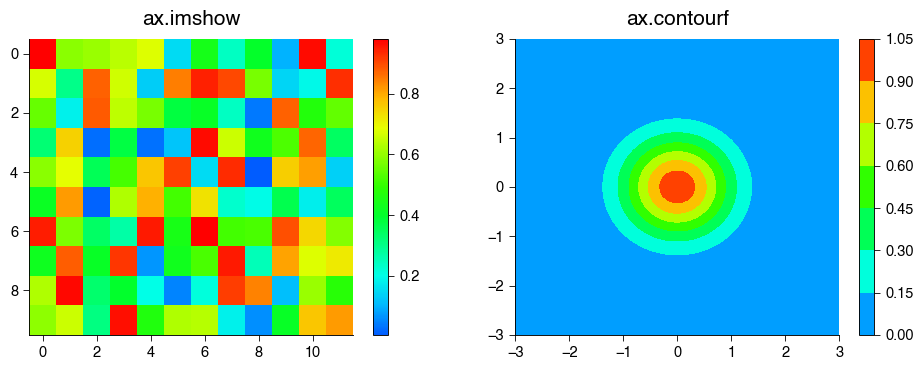

In [28]:
with stata_mpl.theme('heatmap'):
    fig, axs = plt.subplots(1, 2, figsize=(11, 4))
    im = axs[0].imshow(rng.random((10, 12))); axs[0].set_title('ax.imshow')
    fig.colorbar(im, ax=axs[0])
    xx = np.linspace(-3, 3, 80); X, Y = np.meshgrid(xx, xx); Z = np.exp(-(X**2 + Y**2))
    cs = axs[1].contourf(X, Y, Z); axs[1].set_title('ax.contourf')
    fig.colorbar(cs, ax=axs[1])
    plt.show()

## 7 — Statistical diagnostics

`stata_mpl.qqplot` draws a normal Q–Q plot with stcolor markers and a red
reference line (the `scipy.stats.probplot` markers would otherwise be pure blue).

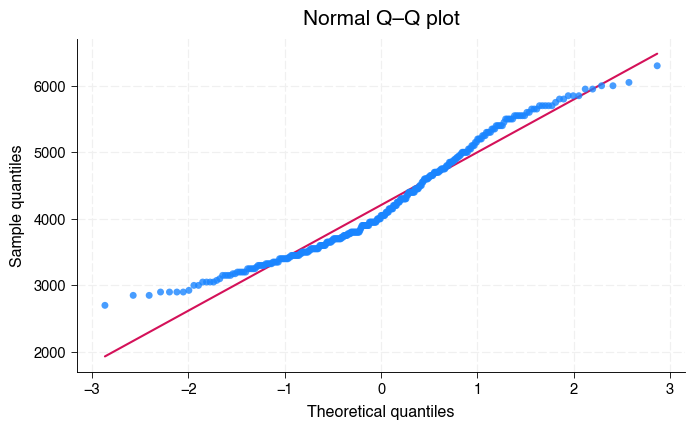

In [29]:
with stata_mpl.theme('scatter'):
    fig, ax = plt.subplots()
    stata_mpl.qqplot(penguins.body_mass_g, ax=ax)
    ax.set_title('Normal Q–Q plot')
    plt.show()

## 8 — Cheat sheet

```python
with stata_mpl.theme(overlay):     # 'line','scatter','bar','histogram','violin','heatmap',...
    ...                            # legends go outside; axvline/axhline are grid-black
```

| Helper | Purpose |
|---|---|
| `stata_mpl.theme(chart=None)` | style + outside legends + grid-black reference lines + seaborn palette |
| `stata_mpl.legend(ax)` | borderless legend outside, right of the frame |
| `stata_mpl.refline(ax, x=, y=)` | reference line: grid dashes, black |
| `stata_mpl.label_points(ax, x, y, labels)` | Stata marker labels (marker color) |
| `stata_mpl.boxplot / violinplot / catplot` | box/violin (incl. facets) with Stata per-group colors |
| `stata_mpl.bubbleplot / pointplot` | hollow-circle bubbles / capped point estimates |
| `stata_mpl.heatmap` | seaborn heatmap, native `stata-heat`, with the cell gap |
| `stata_mpl.jointplot / residplot / qqplot` | de-zoomed joint / grid-black baseline / stcolor Q–Q |
| `stata_mpl.palette(n)` / `lighten(c)` | stcolor colors / Stata light fill |

Continuous-continuous charts (scatter, line, bubble, joint, Q–Q) show **both**
grids; categorical charts (bar, box, violin) keep the horizontal grid only.

**Colormaps:** `stata-heat` (native rainbow), `stata-blue` (sequential),
`stata-bluered` · `stata-bluegreen` · `stata-green-red` · `d-stata-bluered`
(diverging), plus `_r` reversed variants.

**In Jupyter**, keep the wide Stata margins with `stata_mpl.notebook_setup()`.